# The EM Algorithm: Implementation and Verification
**Course:** Machine Learning (20.IDI12) · **Mentor:** Prof. Branimir Todorović · **Author:** Elvir Muslić

The notebook produces every computed number, table and figure in Sections 3 to 7 of the seminar paper *Maximum-Likelihood Estimation and the Expectation–Maximization Algorithm*; the state-space models mentioned in its Section 8 are not coded. The paper's worked values are checked by `assert` statements. Run: `.venv/bin/jupyter nbconvert --to notebook --execute --inplace em_project.ipynb` (packages in `requirements.txt`); the run also writes the figures to `figures/` and the key numbers to `results.json`.

## 1. Theory (brief)
Observed data $x$, latent variable $z$, parameter $\theta$. The observed-data log-likelihood is $\ell(\theta)=\log p(x\mid\theta)=\log\sum_z p(x,z\mid\theta)$, equation (1). For any distribution $q(z)$ Jensen's inequality gives the **lower bound** (2), with the gap (3)
$$\ell(\theta)\;\ge\;\mathcal F(q,\theta)=\sum_z q(z)\log\frac{p(x,z\mid\theta)}{q(z)},\qquad \ell(\theta)-\mathcal F(q,\theta)=\mathrm{KL}\big(q\,\|\,p(\cdot\mid x,\theta)\big)\ge 0 .$$

**E-step:** $q(z)=p(z\mid x,\theta^{(t)})$, which closes the gap. **M-step:** $\theta^{(t+1)}=\arg\max_\theta Q(\theta\mid\theta^{(t)})$ with $Q$ from (4). EM is coordinate ascent on $\mathcal F$.

**Theorem 3.1 (monotone ascent):** $\ell(\theta^{(t+1)})\ge\ell(\theta^{(t)})$. By (5), $\ell(\theta)-\ell(\theta^{(t)})=\big[Q(\theta\mid\theta^{(t)})-Q(\theta^{(t)}\mid\theta^{(t)})\big]+\mathrm{KL}\ge 0$ at $\theta=\theta^{(t+1)}$.

Near a maximum the convergence is **linear**. For a single parameter the factor by which the error shrinks equals the slope of the EM map at $\hat\theta$, which is the **fraction of missing information** $1-I_{\mathrm{obs}}/I_c$, equation (7) of the paper (Dempster, Laird and Rubin 1977, Section 3).

### Code and data
Two cells hold all the code: the linkage EM, equations (9) and (10), and a Gaussian-mixture EM written from scratch in PyTorch (responsibilities (12) via log-sum-exp, M-step (13)). All computations are in float64.

In [1]:
import csv
import json
import math
import platform
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import sklearn
import torch
from matplotlib.patches import Ellipse
from sklearn.mixture import GaussianMixture

T_START = time.perf_counter()
torch.set_default_dtype(torch.float64)
torch.manual_seed(0)

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)
RESULTS = {}                 # numbers quoted by the paper, written to results.json at the end
COL_W = 5.0                  # text width of the one-column A4 paper, in inches
plt.rcParams.update({"font.size": 9, "axes.labelsize": 9, "axes.titlesize": 9,
                     "legend.fontsize": 7.5, "xtick.labelsize": 8, "ytick.labelsize": 8,
                     "pdf.fonttype": 42, "figure.dpi": 110})


def check(condition, message):
    """Stop the notebook if a reproduction is off; otherwise print one check line."""
    assert condition, f"FAILED: {message}"
    print(f"check: {message} ✓")


def save(fig, name):
    """Save a figure as vector PDF for the paper and register it in the results."""
    fig.savefig(FIG_DIR / name, bbox_inches="tight")
    RESULTS.setdefault("figures", []).append(f"figures/{name}")

In [2]:
# ---------- Genetic linkage (paper, Section 5) ----------
Y = torch.tensor([125.0, 18.0, 20.0, 34.0])       # observed counts y1, ..., y4


def linkage_loglik(theta, y=Y):
    """Observed-data log-likelihood, up to the multinomial constant."""
    theta = torch.as_tensor(theta)
    p = torch.stack([0.5 + theta / 4, (1 - theta) / 4, (1 - theta) / 4, theta / 4])
    return float((y * torch.log(p)).sum())


def linkage_em_step(theta, y=Y):
    """One EM iteration: E-step (9) gives E[z], M-step (10) gives the new theta."""
    expected_z = y[0] * (theta / 4) / (0.5 + theta / 4)
    new_theta = (expected_z + y[3]) / (expected_z + y[1] + y[2] + y[3])
    return expected_z, new_theta


# ---------- Gaussian mixture (paper, Section 6) ----------
LOG_2PI = math.log(2 * math.pi)


def log_gaussian(x, mu, sigma):
    """log N(x_i | mu_k, Sigma_k) for all points i and components k, via Cholesky; shape (n, K)."""
    chol = torch.linalg.cholesky(sigma)                                   # (K, d, d)
    centered = (x[None, :, :] - mu[:, None, :]).transpose(1, 2)           # (K, d, n)
    z = torch.linalg.solve_triangular(chol, centered, upper=False)        # (K, d, n)
    mahalanobis = (z ** 2).sum(dim=1)                                     # (K, n)
    log_det = 2 * torch.log(torch.diagonal(chol, dim1=1, dim2=2)).sum(dim=1)
    return (-0.5 * (mahalanobis + log_det[:, None] + x.shape[1] * LOG_2PI)).T


def e_step(x, pi, mu, sigma):
    """Log-responsibilities log gamma_ik and the log-likelihood l(theta)."""
    log_joint = torch.log(pi)[None, :] + log_gaussian(x, mu, sigma)      # log pi_k N(x_i | ...)
    log_norm = torch.logsumexp(log_joint, dim=1)                         # log p(x_i | theta)
    return log_joint - log_norm[:, None], float(log_norm.sum())


def m_step(x, resp, ridge=0.0):
    """Responsibility-weighted ML estimates (13); ridge > 0 adds ridge * I to every covariance."""
    n, d = x.shape
    n_k = resp.sum(dim=0)
    pi = n_k / n
    mu = resp.T @ x / n_k[:, None]
    centered = x[None, :, :] - mu[:, None, :]                             # (K, n, d)
    sigma = torch.einsum("nk,kni,knj->kij", resp, centered, centered) / n_k[:, None, None]
    return pi, mu, sigma + ridge * torch.eye(d)


def lower_bound(x, pi, mu, sigma, log_resp):
    """The bound F(q, theta) of equation (2), with q given by log_resp."""
    log_joint = torch.log(pi)[None, :] + log_gaussian(x, mu, sigma)
    return float((log_resp.exp() * (log_joint - log_resp)).sum())


def run_em(x, pi, mu, sigma, max_iter=2000, tol=1e-10, ridge=0.0, keep=()):
    """EM until |l(theta_t) - l(theta_t-1)| < tol (tol < 0: exactly max_iter iterations).

    Returns the final parameters, l(theta_t) for every t, snapshots at the iterations in `keep`
    and the smallest covariance eigenvalue met along the way."""
    logliks, snapshots, min_eig = [], {}, math.inf
    for t in range(max_iter + 1):
        log_resp, loglik = e_step(x, pi, mu, sigma)
        logliks.append(loglik)
        min_eig = min(min_eig, float(torch.linalg.eigvalsh(sigma).min()))
        if t in keep:
            snapshots[t] = (pi, mu, sigma, log_resp.exp())
        if (t > 0 and abs(logliks[-1] - logliks[-2]) < tol) or t == max_iter:
            break
        pi, mu, sigma = m_step(x, log_resp.exp(), ridge)
    snapshots["final"] = (pi, mu, sigma, log_resp.exp())
    return {"pi": pi, "mu": mu, "sigma": sigma, "logliks": logliks,
            "n_iter": len(logliks) - 1, "snapshots": snapshots, "min_eig": min_eig}

In [3]:
# Old Faithful: 272 observations of eruption duration and waiting time to the next eruption,
# in minutes: R's `faithful` data (Azzalini and Bowman 1990 analyse a more complete record), as in Bishop (2006), Ch. 9.
# File: R datasets via Rdatasets, https://vincentarelbundock.github.io/Rdatasets/csv/datasets/faithful.csv
with open("data/faithful.csv", newline="") as fh:
    rows = list(csv.DictReader(fh))
X_RAW = torch.tensor([[float(r["eruptions"]), float(r["waiting"])] for r in rows])
check(tuple(X_RAW.shape) == (272, 2), "Old Faithful has n = 272 observations")
check(abs(float(X_RAW[:, 0].mean()) - 3.487783) < 5e-7 and abs(float(X_RAW[:, 1].mean()) - 70.897059) < 5e-7,
      "column means 3.487783 and 70.897059, as in R")
CENTER, SCALE = X_RAW.mean(dim=0), X_RAW.std(dim=0, correction=0)
X = (X_RAW - CENTER) / SCALE            # standardized, as in Bishop's figures

# Deliberately poor start used in Sections 3 and 6: two unit circles at the upper left and lower right
INIT = (torch.tensor([0.5, 0.5]), torch.tensor([[-1.5, 1.5], [1.5, -1.5]]), torch.eye(2).repeat(2, 1, 1))

check: Old Faithful has n = 272 observations ✓
check: column means 3.487783 and 70.897059, as in R ✓


## 2. Genetic linkage (DLR)
Dempster, Laird and Rubin (1977) classify 197 animals into four categories, $y=(125,18,20,34)$, with cell probabilities $\big(\tfrac12+\tfrac\theta4,\ \tfrac{1-\theta}4,\ \tfrac{1-\theta}4,\ \tfrac\theta4\big)$. The first category mixes two sources; the count $z$ coming from the $\tfrac\theta4$ part is latent.

E-step (9): $\ \mathbb E[z]=y_1\,\dfrac{\theta^{(t)}/4}{1/2+\theta^{(t)}/4}$. M-step (10): $\ \theta^{(t+1)}=\dfrac{\mathbb E[z]+y_4}{\mathbb E[z]+y_2+y_3+y_4}$.

Setting $\ell'(\theta)=0$ gives $197\theta^2-15\theta-68=0$, so the MLE has a closed form, $\hat\theta=(15+\sqrt{53809})/394$, and we can measure the error of every iterate.

In [4]:
n_total = float(Y.sum())
b_coef = float(Y[0] - 2 * (Y[1] + Y[2]) - Y[3])      # score equation: n θ² − b θ − c = 0
c_coef = float(2 * Y[3])
check((n_total, b_coef, c_coef) == (197.0, 15.0, 68.0), "score equation is 197θ² − 15θ − 68 = 0")
theta_hat = (b_coef + math.sqrt(b_coef ** 2 + 4 * n_total * c_coef)) / (2 * n_total)
check(abs(theta_hat - (15 + math.sqrt(53809)) / 394) < 1e-15, f"θ̂ = (15 + √53809)/394 = {theta_hat:.10f}")

thetas, expected_z = [torch.tensor(0.5)], []
for _ in range(12):
    ez, new_theta = linkage_em_step(thetas[-1])
    expected_z.append(float(ez))
    thetas.append(new_theta)
thetas = [float(t) for t in thetas]
ratios = [(thetas[t + 1] - theta_hat) / (thetas[t] - theta_hat) for t in range(11)]

print(" t   θ_t            ℓ(θ_t)            (θ_t+1 − θ̂)/(θ_t − θ̂)")
for t in range(11):
    print(f"{t:2d}   {thetas[t]:.10f}   {linkage_loglik(thetas[t]):.10f}   {ratios[t]:.8f}")

check(expected_z[0] == 25.0, "E[z] = 25 in the first E-step")
check(abs(thetas[1] - 59 / 97) < 1e-15, "θ¹ = 59/97")
PAPER_ITERATES = [0.6082, 0.6243, 0.6265, 0.6268]
check([round(t, 4) for t in thetas[1:5]] == PAPER_ITERATES, "θ¹, …, θ⁴ round to 0.6082, 0.6243, 0.6265, 0.6268 (paper, Section 5)")
check(abs(thetas[12] - theta_hat) < 1e-10, "EM reaches the closed-form MLE: |θ¹² − θ̂| < 1e-10")

check: score equation is 197θ² − 15θ − 68 = 0 ✓
check: θ̂ = (15 + √53809)/394 = 0.6268214979 ✓
 t   θ_t            ℓ(θ_t)            (θ_t+1 − θ̂)/(θ_t − θ̂)
 0   0.5000000000   -208.4702446567   0.14645841
 1   0.6082474227   -205.7798186524   0.13462030
 2   0.6243210504   -205.7170641748   0.13302371
 3   0.6264888791   -205.7159079221   0.13281127
 4   0.6267773223   -205.7158874142   0.13278305
 5   0.6268156321   -205.7158870524   0.13277931
 6   0.6268207190   -205.7158870460   0.13277881
 7   0.6268213945   -205.7158870459   0.13277874
 8   0.6268214841   -205.7158870459   0.13277874
 9   0.6268214960   -205.7158870459   0.13277873
10   0.6268214976   -205.7158870459   0.13277879
check: E[z] = 25 in the first E-step ✓
check: θ¹ = 59/97 ✓
check: θ¹, …, θ⁴ round to 0.6082, 0.6243, 0.6265, 0.6268 (paper, Section 5) ✓
check: EM reaches the closed-form MLE: |θ¹² − θ̂| < 1e-10 ✓


**Rate of convergence.** Near $\hat\theta$ each iteration multiplies the error by an almost constant factor. For this model the observed and the expected complete-data information are, as in equation (11) of the paper,
$$I_{\mathrm{obs}}=\frac{y_1}{(2+\theta)^2}+\frac{y_2+y_3}{(1-\theta)^2}+\frac{y_4}{\theta^2},\qquad
I_c=\frac{\mathbb E[z]+y_4}{\theta^2}+\frac{y_2+y_3}{(1-\theta)^2},\qquad \mathbb E[z]=\frac{y_1\theta}{2+\theta},$$
evaluated at $\hat\theta$. Their difference is the missing information $I_m=I_c-I_{\mathrm{obs}}$. The measured factor and a central difference both estimate the slope $M'(\hat\theta)$ of the EM map; we compare them with $I_m/I_c$, which is computed from the information formulas alone. Automatic differentiation of $\ell$ checks the formulas independently: $\ell'(\hat\theta)=0$ and $-\ell''(\hat\theta)=I_{\mathrm{obs}}$.

I_obs = 377.5169,  I_c = 435.3179,  I_m = 57.8010
fraction of missing information I_m/I_c = 0.13277873
measured factor at t = 8               = 0.13277874
slope of the EM map at θ̂               = 0.13277873
check: measured rate = fraction of missing information (to 1e-6) ✓
check: slope of the EM map = fraction of missing information (to 1e-8) ✓
check: autograd: ℓ'(θ̂) = 7.1e-15, so the closed-form θ̂ is a stationary point of ℓ ✓
check: autograd: −ℓ''(θ̂) = 377.5169003947 = I_obs from the formula (to 1e-9) ✓
check: all six ratios printed in DLR (1977), Table 1, match: 0.1465, 0.1346, 0.1330, 0.1328, 0.1328, 0.1328 ✓


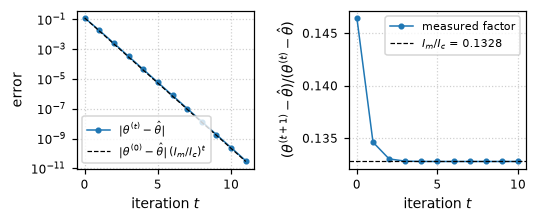

In [5]:
th = theta_hat
info_obs = float(Y[0]) / (2 + th) ** 2 + float(Y[1] + Y[2]) / (1 - th) ** 2 + float(Y[3]) / th ** 2
info_com = (float(Y[0]) * th / (2 + th) + float(Y[3])) / th ** 2 + float(Y[1] + Y[2]) / (1 - th) ** 2
frac_missing = 1 - info_obs / info_com
h = 1e-6
em_map_slope = (float(linkage_em_step(torch.tensor(th + h))[1])
                - float(linkage_em_step(torch.tensor(th - h))[1])) / (2 * h)
print(f"I_obs = {info_obs:.4f},  I_c = {info_com:.4f},  I_m = {info_com - info_obs:.4f}")
print(f"fraction of missing information I_m/I_c = {frac_missing:.8f}")
print(f"measured factor at t = 8               = {ratios[8]:.8f}")
print(f"slope of the EM map at θ̂               = {em_map_slope:.8f}")
check(abs(ratios[8] - frac_missing) < 1e-6, "measured rate = fraction of missing information (to 1e-6)")
check(abs(em_map_slope - frac_missing) < 1e-8, "slope of the EM map = fraction of missing information (to 1e-8)")
# independent check of the hand-derived formulas: differentiate the log-likelihood itself with autograd
theta_ad = torch.tensor(theta_hat, requires_grad=True)
p_ad = torch.stack([0.5 + theta_ad / 4, (1 - theta_ad) / 4, (1 - theta_ad) / 4, theta_ad / 4])
(score_ad,) = torch.autograd.grad((Y * torch.log(p_ad)).sum(), theta_ad, create_graph=True)
(second_ad,) = torch.autograd.grad(score_ad, theta_ad)
score_ad, info_obs_ad = float(score_ad), -float(second_ad)
check(abs(score_ad) < 1e-9, f"autograd: ℓ'(θ̂) = {score_ad:.1e}, so the closed-form θ̂ is a stationary point of ℓ")
check(abs(info_obs_ad - info_obs) < 1e-9, f"autograd: −ℓ''(θ̂) = {info_obs_ad:.10f} = I_obs from the formula (to 1e-9)")

DLR_TABLE1 = [0.1465, 0.1346, 0.1330, 0.1328, 0.1328, 0.1328]   # every ratio DLR (1977) print, t = 0..5
check([round(r, 4) for r in ratios[:6]] == DLR_TABLE1,
      "all six ratios printed in DLR (1977), Table 1, match: 0.1465, 0.1346, 0.1330, 0.1328, 0.1328, 0.1328")

t_axis = np.arange(12)
errors = np.abs(np.array(thetas[:12]) - theta_hat)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(COL_W, 2.1))
ax1.semilogy(t_axis, errors, "o-", ms=3, lw=1, label=r"$|\theta^{(t)}-\hat\theta|$")
ax1.semilogy(t_axis, errors[0] * frac_missing ** t_axis, "k--", lw=0.8, label=r"$|\theta^{(0)}-\hat\theta|\,(I_m/I_c)^t$")
ax1.set_xlabel("iteration $t$")
ax1.set_ylabel("error")
ax1.legend(loc="lower left")
ax1.grid(True, which="major", ls=":", alpha=0.6)
ax2.plot(range(11), ratios, "o-", ms=3, lw=1, label="measured factor")
ax2.axhline(frac_missing, color="k", ls="--", lw=0.8, label=f"$I_m/I_c$ = {frac_missing:.4f}")
ax2.set_xlabel("iteration $t$")
ax2.set_ylabel(r"$(\theta^{(t+1)}-\hat\theta)/(\theta^{(t)}-\hat\theta)$")
ax2.legend(loc="upper right")
ax2.grid(True, ls=":", alpha=0.6)
fig.tight_layout()
save(fig, "linkage_rate.pdf")
plt.show()

RESULTS["linkage"] = {
    "counts_y": [125, 18, 20, 34],
    "theta0": 0.5,
    "score_equation": "197 theta^2 - 15 theta - 68 = 0",
    "mle_closed_form": theta_hat,
    "paper_vs_computed": {
        "E_z_first_step": {"paper": 25, "computed": expected_z[0]},
        "theta_1": {"paper": 0.6082, "computed": thetas[1], "exact": "59/97"},
        "theta_2": {"paper": 0.6243, "computed": thetas[2]},
        "theta_3": {"paper": 0.6265, "computed": thetas[3]},
        "theta_4": {"paper": 0.6268, "computed": thetas[4]},
        "mle": {"paper": 0.6268, "computed": theta_hat},
    },
    "iterates": [{"t": t, "theta": thetas[t], "loglik": linkage_loglik(thetas[t]),
                  "error": thetas[t] - theta_hat, "error_ratio": ratios[t] if t < 11 else None}
                 for t in range(13)],
    "dlr_1977_table1_ratios": {"reported": DLR_TABLE1, "computed": ratios[:6]},
    "autograd": {"score_at_mle": score_ad, "neg_second_derivative_at_mle": info_obs_ad},
    "rate": {"measured_factor_t8": ratios[8], "fraction_missing_information": frac_missing,
             "em_map_slope": em_map_slope, "info_observed": info_obs, "info_complete": info_com,
             "info_missing": info_com - info_obs},
}

## 3. Theorem 3.1, numerically
Two checks of $\ell(\theta^{(t+1)})\ge\ell(\theta^{(t)})$, with tolerance $10^{-9}$ for rounding, and one illustration:
1. the linkage run of Section 2;
2. 60 Gaussian-mixture runs on the Old Faithful data, $K=2$ and $K=3$, 30 random starts each (means at random data points, unit covariances, equal weights);
3. an illustration of the bound on one run: after every E-step $\mathcal F=\ell$, which holds by construction because $q$ is the exact posterior, and $\mathcal F\le\ell$ at every half-step.

The M-step is exact, with no ridge on the covariances; the remark at the end of this section shows why that matters.

In [6]:
linkage_ll = [linkage_loglik(t) for t in thetas]
linkage_min_inc = min(b - a for a, b in zip(linkage_ll, linkage_ll[1:]))
check(linkage_min_inc >= -1e-9, f"linkage: no decrease beyond rounding (smallest increment {linkage_min_inc:.1e})")


def random_start(k, seed):
    """Means at k random data points, unit covariances, equal weights."""
    gen = torch.Generator().manual_seed(seed)
    idx = torch.randperm(X.shape[0], generator=gen)[:k]
    return torch.full((k,), 1.0 / k), X[idx].clone(), torch.eye(2).repeat(k, 1, 1)


def restarts(ridge):
    """30 random starts for K = 2 and for K = 3; increments of l for every run."""
    out = []
    for k in (2, 3):
        for seed in range(30):
            run = run_em(X, *random_start(k, seed), ridge=ridge)
            inc = np.diff(run["logliks"])
            out.append({"K": k, "seed": seed, "n_iter": run["n_iter"], "final": run["logliks"][-1],
                        "min_inc": float(inc.min()), "n_drops": int((inc < -1e-11).sum()),
                        "min_eig": run["min_eig"]})
    return out


runs = restarts(ridge=0.0)
worst = min(r["min_inc"] for r in runs)
n_steps = sum(r["n_iter"] for r in runs)
n_drops = sum(r["n_drops"] for r in runs)
smallest_eig = min(r["min_eig"] for r in runs)
check(len(runs) == 60, "60 runs from random starts")
check(worst >= -1e-9, f"GMM: no decrease in {n_steps} EM iterations (smallest increment {worst:.1e})")
check(smallest_eig > 1e-3, f"covariances stay well conditioned (smallest eigenvalue {smallest_eig:.4f}), so no ridge is needed")

limits = {}                                    # where the runs end: stationary points of ℓ (not shown to be maxima)
for k in (2, 3):
    finals = sorted({round(r["final"], 4) for r in runs if r["K"] == k}, reverse=True)
    limits[k] = []
    for value in finals:
        members = [r for r in runs if r["K"] == k and round(r["final"], 4) == value]
        limits[k].append({"loglik": value, "starts": len(members),
                          "smallest_eigenvalue": min(m["min_eig"] for m in members)})
        print(f"K = {k}: final ℓ = {value:.4f}, reached by {len(members):2d} of 30 starts")
check(len(limits[2]) == 1, "K = 2: every start reaches the same limit")

check: linkage: no decrease beyond rounding (smallest increment -2.8e-14) ✓


check: 60 runs from random starts ✓
check: GMM: no decrease in 6410 EM iterations (smallest increment 7.1e-12) ✓
check: covariances stay well conditioned (smallest eigenvalue 0.0028), so no ridge is needed ✓
K = 2: final ℓ = -385.4607, reached by 30 of 30 starts
K = 3: final ℓ = -369.6366, reached by  3 of 30 starts
K = 3: final ℓ = -374.4107, reached by 20 of 30 starts
K = 3: final ℓ = -374.8414, reached by  7 of 30 starts
check: K = 2: every start reaches the same limit ✓


**The bound.** One run from the poor start of Section 1. The first iteration makes a large jump (printed below), so the plot starts at $\theta^{(1)}$. Black: $\mathcal F$ after each E-step and M-step; red: $\ell(\theta)$ at the current parameter. After an M-step the two separate (the gap is the KL divergence); the next E-step closes it.

first iteration: ℓ(θ⁰) = -1331.4822 → ℓ(θ¹) = -542.9831
check: after every E-step F = ℓ, as it must by construction (largest |ℓ − F| = 1.1e-13) ✓
check: F ≤ ℓ at every half-step ✓
check: F increases at every half-step (coordinate ascent) ✓


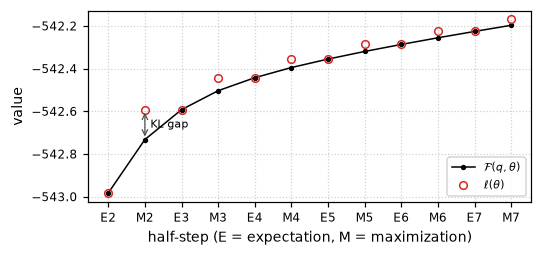

In [7]:
pi, mu, sigma = INIT
steps = []                                    # (half-step, F, l)
for t in range(1, 8):
    log_resp, loglik = e_step(X, pi, mu, sigma)                   # E-step: q = p(z | x, θ^(t-1))
    steps.append((f"E{t}", lower_bound(X, pi, mu, sigma, log_resp), loglik))
    pi, mu, sigma = m_step(X, log_resp.exp())                      # M-step: θ^(t)
    steps.append((f"M{t}", lower_bound(X, pi, mu, sigma, log_resp), e_step(X, pi, mu, sigma)[1]))

gap_after_e = max(abs(f - l) for name, f, l in steps if name[0] == "E")
max_f_minus_l = max(f - l for _, f, l in steps)
f_values = [f for _, f, _ in steps]
print(f"first iteration: ℓ(θ⁰) = {steps[0][2]:.4f} → ℓ(θ¹) = {steps[1][2]:.4f}")
check(gap_after_e < 1e-9, f"after every E-step F = ℓ, as it must by construction (largest |ℓ − F| = {gap_after_e:.1e})")
check(max_f_minus_l < 1e-9, "F ≤ ℓ at every half-step")
check(min(b - a for a, b in zip(f_values, f_values[1:])) > 0, "F increases at every half-step (coordinate ascent)")

shown = steps[2:]                             # from E2, i.e. from θ^(1)
xs = np.arange(len(shown))
fig, ax = plt.subplots(figsize=(COL_W, 2.4))
ax.plot(xs, [f for _, f, _ in shown], "k.-", lw=1, ms=5, label=r"$\mathcal{F}(q,\theta)$")
ax.plot(xs, [l for _, _, l in shown], "o", mfc="none", color="tab:red", ms=5, label=r"$\ell(\theta)$")
ax.set_xticks(xs)
ax.set_xticklabels([name for name, _, _ in shown])
ax.set_xlabel("half-step (E = expectation, M = maximization)")
ax.set_ylabel("value")
i_gap = 1                                     # M2: the largest visible gap
ax.annotate("", xy=(xs[i_gap], shown[i_gap][2]), xytext=(xs[i_gap], shown[i_gap][1]),
            arrowprops=dict(arrowstyle="<->", lw=0.8, color="0.3"))
ax.text(xs[i_gap] + 0.15, (shown[i_gap][1] + shown[i_gap][2]) / 2, "KL gap", fontsize=7.5, va="center")
ax.legend(loc="lower right")
ax.grid(True, ls=":", alpha=0.6)
fig.tight_layout()
save(fig, "staircase.pdf")
plt.show()

**Remark: why no ridge.** A common safeguard (`reg_covar` in scikit-learn) adds $\lambda I$ to every covariance after the M-step. Then $\theta^{(t+1)}$ no longer maximizes $Q(\cdot\mid\theta^{(t)})$, and near convergence it need not even increase $Q$, which is all the proof of Theorem 3.1 uses. The same 60 starts with $\lambda=10^{-6}$:

In [8]:
runs_ridge = restarts(ridge=1e-6)
worst_ridge = min(r["min_inc"] for r in runs_ridge)
n_drops_ridge = sum(r["n_drops"] for r in runs_ridge)
runs_with_drops = sum(r["n_drops"] > 0 for r in runs_ridge)
print(f"λ = 1e-6: ℓ decreased (by more than 1e-11) in {n_drops_ridge} iterations of {runs_with_drops} runs; "
      f"largest decrease {-worst_ridge:.1e}")
print(f"λ = 0   : {n_drops} such iterations")
check(n_drops == 0, "exact M-step: ℓ never decreases by more than rounding (1e-11)")

RESULTS["theorem_3_1"] = {
    "linkage_min_increment": linkage_min_inc,
    "gmm_runs": len(runs), "K_values": [2, 3], "starts_per_K": 30,
    "total_em_iterations": n_steps, "min_increment": worst,
    "decreases_below_1e-11": n_drops, "smallest_covariance_eigenvalue": smallest_eig,
    "limits": {f"K={k}": v for k, v in limits.items()},
    "bound": {"max_abs_gap_after_E": gap_after_e, "max_F_minus_l": max_f_minus_l,
              "first_iteration": {"loglik_theta0": steps[0][2], "loglik_theta1": steps[1][2]}},
    "ridge_1e-6": {"decreases_below_1e-11": n_drops_ridge, "runs_with_decreases": runs_with_drops,
                   "largest_decrease": -worst_ridge, "total_em_iterations": sum(r["n_iter"] for r in runs_ridge)},
}

λ = 1e-6: ℓ decreased (by more than 1e-11) in 7 iterations of 2 runs; largest decrease 8.5e-10
λ = 0   : 0 such iterations
check: exact M-step: ℓ never decreases by more than rounding (1e-11) ✓


## 4. Gaussian mixtures (EM from scratch)
The E-step (12) and M-step (13) are the functions `e_step` and `m_step` of Section 1: no mixture library, vectorized over points and components. First the paper's concrete E-step (Section 6): two unit-variance components at $\mu_1=0$ and $\mu_2=2$ with equal weights give the point $x=0.5$ the responsibilities $(0.731059,\,0.268941)$.

In [9]:
log_resp, _ = e_step(torch.tensor([[0.5]]), torch.tensor([0.5, 0.5]),
                     torch.tensor([[0.0], [2.0]]), torch.eye(1).repeat(2, 1, 1))
gamma = [float(g) for g in log_resp.exp()[0]]
print(f"γ = ({gamma[0]:.6f}, {gamma[1]:.6f})")
check([round(g, 6) for g in gamma] == [0.731059, 0.268941], "responsibilities (0.731059, 0.268941) as in the paper, Section 6")
check(abs(gamma[0] - 1 / (1 + math.exp(-1))) < 1e-15, "γ₁ = 1/(1 + e⁻¹) exactly")

γ = (0.731059, 0.268941)
check: responsibilities (0.731059, 0.268941) as in the paper, Section 6 ✓
check: γ₁ = 1/(1 + e⁻¹) exactly ✓


**Old Faithful, $K=2$,** from the poor start of Section 1. The figure follows Bishop (2006, Fig. 9.8): every point is colored by its responsibilities (red and blue, purple when shared), with the $1\sigma$ (solid) and $2\sigma$ (dashed) contours of each component.

converged after 53 iterations: ℓ = -385.460696 (-1.417135 per point)
check: EM converged (|Δℓ| < 1e-10) ✓
check: ℓ increases at every iteration of this run ✓


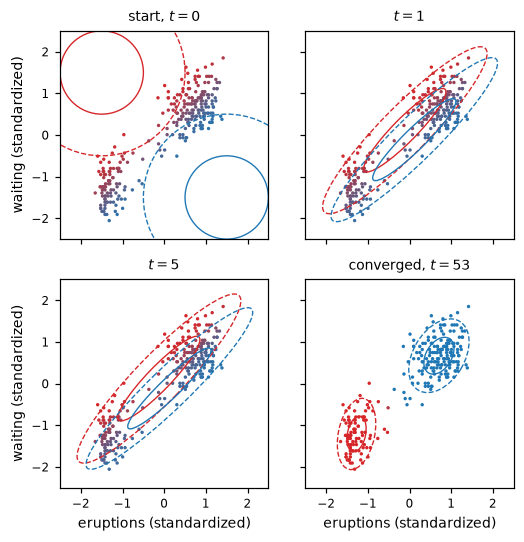

In [10]:
fit = run_em(X, *INIT, keep=(0, 1, 5))
n_points = X.shape[0]
print(f"converged after {fit['n_iter']} iterations: ℓ = {fit['logliks'][-1]:.6f} ({fit['logliks'][-1] / n_points:.6f} per point)")
check(fit["n_iter"] < 2000, "EM converged (|Δℓ| < 1e-10)")
check(bool(np.all(np.diff(fit["logliks"]) >= -1e-9)), "ℓ increases at every iteration of this run")

RED, BLUE = np.array([0.84, 0.15, 0.16]), np.array([0.12, 0.47, 0.71])


def draw_state(ax, state, title):
    """Points colored by responsibility, 1σ and 2σ ellipses of both components."""
    pi, mu, sigma, resp = state
    colors = np.clip(resp[:, :1].numpy() * RED + resp[:, 1:2].numpy() * BLUE, 0, 1)
    ax.scatter(X[:, 0].numpy(), X[:, 1].numpy(), c=colors, s=5, linewidths=0)
    for k, col in enumerate((RED, BLUE)):
        vals, vecs = torch.linalg.eigh(sigma[k])                  # ascending eigenvalues
        angle = math.degrees(math.atan2(float(vecs[1, 1]), float(vecs[0, 1])))
        for n_sd, style in ((1, "-"), (2, "--")):
            ax.add_patch(Ellipse(mu[k].numpy(), 2 * n_sd * math.sqrt(float(vals[1])),
                                 2 * n_sd * math.sqrt(float(vals[0])), angle=angle,
                                 fill=False, color=col, lw=0.9, ls=style))
    ax.set_title(title)
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    ax.set_aspect("equal")


fig, axes = plt.subplots(2, 2, figsize=(COL_W, COL_W), sharex=True, sharey=True)
panels = [(0, "start, $t=0$"), (1, "$t=1$"), (5, "$t=5$"), ("final", f"converged, $t={fit['n_iter']}$")]
for ax, (key, title) in zip(axes.flat, panels):
    draw_state(ax, fit["snapshots"][key], title)
for ax in axes[1]:
    ax.set_xlabel("eruptions (standardized)")
for ax in axes[:, 0]:
    ax.set_ylabel("waiting (standardized)")
fig.tight_layout()
save(fig, "gmm_iterations.pdf")
plt.show()

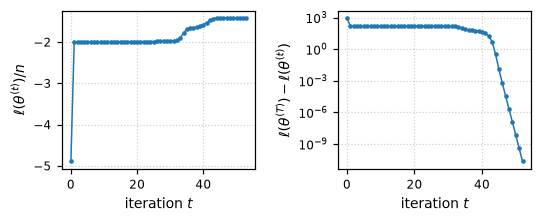

one Gaussian for all points: ℓ/n = -2.0037; after one EM iteration: ℓ/n = -1.9963, both means within 0.1617 of the data mean
EM covers half of the remaining gain only at iteration t = 35
check: after one iteration EM is next to the one-Gaussian fit (ℓ/n within 0.01) ✓
component  weight   mean eruptions  mean waiting   sd eruptions  sd waiting  correlation
        1  0.3559     2.0364        54.4785       0.2630       5.8049     0.2850
        2  0.6441     4.2897        79.9681       0.4123       6.0038     0.3800
check: weights sum to 1 ✓


In [11]:
ll = np.array(fit["logliks"])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(COL_W, 2.1))
ax1.plot(ll / n_points, "o-", ms=2, lw=1)
ax1.set_xlabel("iteration $t$")
ax1.set_ylabel(r"$\ell(\theta^{(t)})/n$")
ax1.grid(True, ls=":", alpha=0.6)
ax2.semilogy(ll[-1] - ll[:-1], "o-", ms=2, lw=1)
ax2.set_xlabel("iteration $t$")
ax2.set_ylabel(r"$\ell(\theta^{(T)})-\ell(\theta^{(t)})$")
ax2.grid(True, which="major", ls=":", alpha=0.6)
fig.tight_layout()
save(fig, "loglik.pdf")
plt.show()

# The flat stretch: one Gaussian fitted to all points is the EM fixed point where both components coincide
one_gauss = float(log_gaussian(X, X.mean(dim=0, keepdim=True), torch.cov(X.T, correction=0)[None]).sum()) / n_points
mean_offset = float(fit["snapshots"][1][1].norm(dim=1).max())     # the standardized data have mean 0
t_half = int(np.argmax(ll >= (ll[1] + ll[-1]) / 2))              # first t past half of the remaining gain
print(f"one Gaussian for all points: ℓ/n = {one_gauss:.4f}; after one EM iteration: ℓ/n = {ll[1] / n_points:.4f}, "
      f"both means within {mean_offset:.4f} of the data mean")
print(f"EM covers half of the remaining gain only at iteration t = {t_half}")
check(abs(ll[1] / n_points - one_gauss) < 0.01, "after one iteration EM is next to the one-Gaussian fit (ℓ/n within 0.01)")

# final parameters in the original units (minutes)
pi, mu, sigma = fit["pi"], fit["mu"], fit["sigma"]
mu_orig = mu * SCALE + CENTER
sigma_orig = sigma * (SCALE[:, None] * SCALE[None, :])
components = []
print("component  weight   mean eruptions  mean waiting   sd eruptions  sd waiting  correlation")
for k in range(2):
    sd = torch.sqrt(torch.diagonal(sigma_orig[k]))
    rho = float(sigma_orig[k][0, 1] / (sd[0] * sd[1]))
    components.append({"weight": float(pi[k]), "mean_eruptions_min": float(mu_orig[k, 0]),
                       "mean_waiting_min": float(mu_orig[k, 1]), "sd_eruptions_min": float(sd[0]),
                       "sd_waiting_min": float(sd[1]), "correlation": rho,
                       "covariance_min2": sigma_orig[k].tolist()})
    print(f"{k + 1:9d}  {float(pi[k]):.4f}   {float(mu_orig[k, 0]):8.4f}       {float(mu_orig[k, 1]):8.4f}     "
          f"{float(sd[0]):8.4f}     {float(sd[1]):8.4f}    {rho:7.4f}")
check(abs(sum(c["weight"] for c in components) - 1) < 1e-12, "weights sum to 1")

RESULTS["gmm"] = {
    "data": {"name": "Old Faithful", "n": n_points, "means_raw": X_RAW.mean(dim=0).tolist(),
             "source": "https://vincentarelbundock.github.io/Rdatasets/csv/datasets/faithful.csv",
             "standardization": "z-score, population standard deviation"},
    "responsibility_example": {"paper": [0.731059, 0.268941], "computed": gamma},
    "init_standardized": {"weights": [0.5, 0.5], "means": [[-1.5, 1.5], [1.5, -1.5]], "covariances": "identity"},
    "n_iter": fit["n_iter"], "loglik_total": fit["logliks"][-1], "loglik_per_point": fit["logliks"][-1] / n_points,
    "one_gaussian_loglik_per_point": one_gauss, "loglik_per_point_t1": float(ll[1] / n_points),
    "max_mean_offset_t1": mean_offset, "max_mean_offset_t1_ceil_2dp": math.ceil(mean_offset * 100) / 100,
    "t_half_remaining_gain": t_half,
    "components_original_units": components,
}

## 5. Comparison with scikit-learn
`GaussianMixture` runs the same EM. It gets the same starting weights, means and precisions (inverse covariances), full covariances, `reg_covar = 0` (our M-step has no ridge) and tolerance $10^{-10}$. scikit-learn stops by its own rule; we then run our implementation for exactly as many iterations and compare. The two iteration counts differ for two reasons: scikit-learn applies the tolerance to the change of the mean log-likelihood per point (a test $n=272$ times looser), and it tests that change one M-step late. A control fit with tolerance $10^{-10}/n$ checks this.

In [12]:
pi0, mu0, sigma0 = INIT
gm = GaussianMixture(n_components=2, covariance_type="full", tol=1e-10, reg_covar=0.0, max_iter=1000,
                     weights_init=pi0.numpy(), means_init=mu0.numpy(),
                     precisions_init=np.linalg.inv(sigma0.numpy()), random_state=0)
gm.fit(X.numpy())
ours = run_em(X, *INIT, max_iter=gm.n_iter_, tol=-1.0)
diffs = {"weights": float(np.abs(gm.weights_ - ours["pi"].numpy()).max()),
         "means": float(np.abs(gm.means_ - ours["mu"].numpy()).max()),
         "covariances": float(np.abs(gm.covariances_ - ours["sigma"].numpy()).max()),
         "mean_loglik": abs(float(gm.score(X.numpy())) - ours["logliks"][-1] / n_points)}
print(f"scikit-learn {sklearn.__version__}: {gm.n_iter_} iterations, converged = {gm.converged_}")
for name, value in diffs.items():
    print(f"  max |difference| in {name:12s} {value:.1e}")
check(bool(gm.converged_), "scikit-learn converged")
check(ours["n_iter"] == gm.n_iter_, f"our comparison run was stopped after scikit-learn's {gm.n_iter_} iterations")
check(max(diffs["weights"], diffs["means"], diffs["covariances"]) <= 1e-6, "same parameters as scikit-learn (max |difference| ≤ 1e-6)")
check(diffs["mean_loglik"] <= 1e-8, "same mean log-likelihood as scikit-learn (difference ≤ 1e-8)")

# why the counts differ: the per-observation test alone would stop at t_per_obs, and scikit-learn tests one M-step late
per_obs_change = np.abs(np.diff(np.array(fit["logliks"]))) / n_points
t_per_obs = int(np.argmax(per_obs_change < 1e-10)) + 1          # first t >= 1 with |ℓ_t − ℓ_(t−1)|/n < 1e-10
gm_ctrl = GaussianMixture(n_components=2, covariance_type="full", tol=1e-10 / n_points, reg_covar=0.0, max_iter=1000,
                          weights_init=pi0.numpy(), means_init=mu0.numpy(),
                          precisions_init=np.linalg.inv(sigma0.numpy()), random_state=0).fit(X.numpy())
print(f"our run under the per-observation test would stop at t = {t_per_obs}; scikit-learn stops after {gm.n_iter_}")
print(f"control with tol = 1e-10/n: scikit-learn stops after {gm_ctrl.n_iter_}; our rule (1e-10 on the total) after {fit['n_iter']}")
check(gm.n_iter_ == t_per_obs + 1, f"scikit-learn's {gm.n_iter_} iterations = {t_per_obs} (per-observation test) + 1 (tested one M-step late)")
check(gm_ctrl.n_iter_ == fit["n_iter"] + 1, f"control: with tol = 1e-10/n scikit-learn stops after {gm_ctrl.n_iter_} = our {fit['n_iter']} + 1")

RESULTS["sklearn"] = {"version": sklearn.__version__, "n_iter": int(gm.n_iter_), "converged": bool(gm.converged_),
                      "tol": 1e-10, "reg_covar": 0.0, "max_abs_diff": diffs,
                      "per_observation_test_first_t": t_per_obs, "ours_n_iter_tol_1e-10": fit["n_iter"],
                      "control": {"tol": 1e-10 / n_points, "n_iter": int(gm_ctrl.n_iter_)}}

scikit-learn 1.9.1: 52 iterations, converged = True
  max |difference| in weights      5.6e-17
  max |difference| in means        6.7e-16
  max |difference| in covariances  1.4e-16
  max |difference| in mean_loglik  0.0e+00
check: scikit-learn converged ✓
check: our comparison run was stopped after scikit-learn's 52 iterations ✓
check: same parameters as scikit-learn (max |difference| ≤ 1e-6) ✓
check: same mean log-likelihood as scikit-learn (difference ≤ 1e-8) ✓
our run under the per-observation test would stop at t = 51; scikit-learn stops after 52
control with tol = 1e-10/n: scikit-learn stops after 54; our rule (1e-10 on the total) after 53
check: scikit-learn's 52 iterations = 51 (per-observation test) + 1 (tested one M-step late) ✓
check: control: with tol = 1e-10/n scikit-learn stops after 54 = our 53 + 1 ✓


In [13]:
RESULTS["runtime_seconds"] = round(time.perf_counter() - T_START, 2)
RESULTS["versions"] = {"python": platform.python_version(), "python_executable": sys.executable,
                       "torch": torch.__version__, "numpy": np.__version__, "scikit_learn": sklearn.__version__}
Path("results.json").write_text(json.dumps(RESULTS, indent=2, ensure_ascii=False) + "\n")
print(f"results.json written ({len(RESULTS['figures'])} figures in figures/); compute time {RESULTS['runtime_seconds']} s")

# the numbers quoted in the Conclusion below must be the ones computed above
QUOTED = {"theta_hat_10": 0.6268214979, "rate_5": 0.13278, "frac_5": 0.13278, "info_obs_2": 377.52, "info_com_2": 435.32, "info_mis_2": 57.8, "gmm_steps": 6410, "ridge_drops": 7, "ridge_runs": 2, "ridge_max_1sig": 8.5e-10, "k2_loglik": -385.4607, "k3_maxima": [[-369.6366, 3], [-374.4107, 20], [-374.8414, 7]], "fit_iters": 53, "fit_ll_per_point_5": -1.41713, "one_gauss_3": -2.004, "ll1_3": -1.996, "t_half": 35, "weights_3": [0.356, 0.644], "erupt_2": [2.04, 4.29], "wait_1": [54.5, 80.0], "sk_iters": 52, "sk_t_per_obs": 51, "sk_ctrl_iters": 54, "sk_maxdiff_1sig": 6.7e-16}
if QUOTED:
    L, Tm, G = RESULTS["linkage"], RESULTS["theorem_3_1"], RESULTS["gmm"]
    comp = G["components_original_units"]
    computed = {
        "theta_hat_10": round(L["mle_closed_form"], 10),
        "rate_5": round(L["rate"]["measured_factor_t8"], 5),
        "frac_5": round(L["rate"]["fraction_missing_information"], 5),
        "info_obs_2": round(L["rate"]["info_observed"], 2),
        "info_com_2": round(L["rate"]["info_complete"], 2),
        "info_mis_2": round(L["rate"]["info_missing"], 2),
        "gmm_steps": Tm["total_em_iterations"],
        "ridge_drops": Tm["ridge_1e-6"]["decreases_below_1e-11"],
        "ridge_runs": Tm["ridge_1e-6"]["runs_with_decreases"],
        "ridge_max_1sig": float(f"{Tm['ridge_1e-6']['largest_decrease']:.1e}"),
        "k2_loglik": Tm["limits"]["K=2"][0]["loglik"],
        "k3_maxima": [[m["loglik"], m["starts"]] for m in Tm["limits"]["K=3"]],
        "fit_iters": G["n_iter"],
        "fit_ll_per_point_5": round(G["loglik_per_point"], 5),
        "one_gauss_3": round(G["one_gaussian_loglik_per_point"], 3),
        "ll1_3": round(G["loglik_per_point_t1"], 3),
        "t_half": G["t_half_remaining_gain"],
        "weights_3": [round(c["weight"], 3) for c in comp],
        "erupt_2": [round(c["mean_eruptions_min"], 2) for c in comp],
        "wait_1": [round(c["mean_waiting_min"], 1) for c in comp],
        "sk_iters": RESULTS["sklearn"]["n_iter"],
        "sk_t_per_obs": RESULTS["sklearn"]["per_observation_test_first_t"],
        "sk_ctrl_iters": RESULTS["sklearn"]["control"]["n_iter"],
        "sk_maxdiff_1sig": float(f"{max(RESULTS['sklearn']['max_abs_diff'][k] for k in ('weights', 'means', 'covariances')):.1e}"),
    }
    check(computed == QUOTED, f"all {len(QUOTED)} numbers quoted in the Conclusion match this run")

results.json written (4 figures in figures/); compute time 9.23 s
check: all 24 numbers quoted in the Conclusion match this run ✓


## 6. Conclusion
- **Genetic linkage.** From $\theta^{(0)}=0.5$, EM reproduces the paper's iterates 0.6082, 0.6243, 0.6265, 0.6268 and reaches the closed-form MLE $\hat\theta=0.6268214979$ to better than $10^{-10}$ in 12 iterations.
- **Rate.** The error shrinks by the factor 0.13278 per iteration. This ratio and a central difference both estimate the slope of the EM map, and they agree with the independently computed fraction of missing information $I_m/I_c=57.80/435.32=0.13278$ (with $I_{\mathrm{obs}}=377.52$, which automatic differentiation of $\ell$ reproduces). All six ratios printed in Table 1 of Dempster, Laird and Rubin (1977) agree.
- **Theorem 3.1.** $\ell$ never decreased beyond rounding error: not in the linkage run, and not in 6410 EM iterations of 60 Gaussian-mixture runs. In the run of the staircase plot the bound met $\ell$ after every E-step, as it must by construction, and never exceeded it. With a ridge $\lambda=10^{-6}$ on the covariances, $\ell$ decreased in 7 iterations of 2 runs, by up to $8.5\cdot 10^{-10}$. The theorem relies on the M-step being exact.
- **Limits from random starts.** With $K=2$ all 30 starts reach $\ell=-385.4607$. With $K=3$ the starts end at three different stationary points: $\ell=-369.6366$ (3 of 30 starts); $\ell=-374.4107$ (20 of 30 starts); $\ell=-374.8414$ (7 of 30 starts). The highest, $\ell=-369.6366$, is reached by 3 of 30. EM finds stationary points, not necessarily the global maximum, as the paper's conclusion states.
- **Old Faithful.** From a poor start, EM converges in 53 iterations ($\ell/n=-1.41713$). The first iteration brings both components next to the one-Gaussian fit ($\ell/n=-1.996$ against $-2.004$ for a single Gaussian), the fixed point where the two components coincide. EM leaves it slowly and covers half of the remaining gain only at iteration 35: the flat stretch of the log-likelihood plot. The result separates short eruptions (2.04 min, next wait 54.5 min, weight 0.356) from long ones (4.29 min, wait 80.0 min, weight 0.644).
- **scikit-learn.** scikit-learn stops after 52 iterations and our rule after 53: scikit-learn's per-observation test alone would stop at $t=51$, and it tests one M-step late; with tolerance $10^{-10}/n$ it stops after 54. After the same 52 iterations from the same start, scikit-learn's `GaussianMixture` and this from-scratch PyTorch implementation give the same parameters and log-likelihood up to rounding: the largest parameter difference is $6.7\cdot 10^{-16}$ (Section 5).